# Experiment No. 8
## Comparison of Different Classification Algorithms

### Aim
To implement and compare multiple classification algorithms on a dataset and
evaluate their performance using Precision, Recall, and Accuracy metrics.

### Dataset
Iris Dataset

### Problem Statement
Classify flowers into three species — Setosa, Versicolor, and Virginica —
based on their sepal and petal dimensions.

### Objectives

1. To study and understand different machine learning classification algorithms.
2. To apply different classification algorithms to the same dataset.
3. To calculate Accuracy, Precision, Recall and F1-Score for each classifier.
4. To compare the classifiers and identify the most suitable algorithm for the given problem.

### Theory

Classification is a supervised machine learning technique in which the model
learns from labelled training data and assigns new observations to predefined
classes or categories.

In this experiment, the Iris dataset is used to classify flowers into three
species: Setosa, Versicolor and Virginica. Different classification algorithms
are applied to the same dataset and their performances are compared using
Accuracy, Precision, Recall and F1-Score.

The algorithms considered in this experiment are Logistic Regression, Decision
Tree, Random Forest, Support Vector Machine (SVM), K-Nearest Neighbors (KNN)
and Naïve Bayes.

In [2]:
# Import libraries required for data analysis, preprocessing, classification and evaluation

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import time

print("All required libraries imported successfully.")

All required libraries imported successfully.


In [3]:
# Load the headerless Iris dataset and assign meaningful column names

file_path = r"C:\Users\USER\Downloads\iris.csv"

df = pd.read_csv(
    file_path,
    header=None,
    names=[
        "SepalLength",
        "SepalWidth",
        "PetalLength",
        "PetalWidth",
        "Species"
    ]
)

print("Iris dataset loaded successfully.")

Iris dataset loaded successfully.


In [4]:
# Display the first five records of the dataset

df.head()

,SepalLength,SepalWidth,PetalLength,PetalWidth,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [5]:
# Display the dimensions of the dataset

print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])
print("Dataset shape:", df.shape)

Number of rows: 150
Number of columns: 5
Dataset shape: (150, 5)


In [6]:
# Display information about columns, data types and non-null values

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   SepalLength  150 non-null    float64
 1   SepalWidth   150 non-null    float64
 2   PetalLength  150 non-null    float64
 3   PetalWidth   150 non-null    float64
 4   Species      150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 7.9 KB


In [7]:
# Generate descriptive statistics for numerical features

df.describe()

,SepalLength,SepalWidth,PetalLength,PetalWidth
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [8]:
# Check for missing values in the dataset

print("Missing values in each column:")
print(df.isnull().sum())

print("\nTotal missing values:", df.isnull().sum().sum())

Missing values in each column:
SepalLength    0
SepalWidth     0
PetalLength    0
PetalWidth     0
Species        0
dtype: int64

Total missing values: 0


In [9]:
# Display the column names of the dataset

print("Column names:")
print(df.columns.tolist())

Column names:
['SepalLength', 'SepalWidth', 'PetalLength', 'PetalWidth', 'Species']


In [10]:
# Count the number of samples belonging to each flower species

class_counts = df["Species"].value_counts()

print("Number of samples in each species:")
print(class_counts)

Number of samples in each species:
Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


In [11]:
# Separate input features and target variable

X = df[
    [
        "SepalLength",
        "SepalWidth",
        "PetalLength",
        "PetalWidth"
    ]
]

y = df["Species"]

print("Input features:")
print(X.columns.tolist())

print("\nTarget variable:", y.name)

Input features:
['SepalLength', 'SepalWidth', 'PetalLength', 'PetalWidth']

Target variable: Species


In [12]:
# Convert categorical species labels into numerical class labels

label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

print("Original classes:")
print(label_encoder.classes_)

print("\nEncoded classes:")
print(np.unique(y_encoded))

Original classes:
['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']

Encoded classes:
[0 1 2]


In [13]:
# Display original species labels and their encoded values

encoded_data = pd.DataFrame({
    "Original Species": y,
    "Encoded Class": y_encoded
})

encoded_data.head(10)

,Original Species,Encoded Class
0,Iris-setosa,0
1,Iris-setosa,0
2,Iris-setosa,0
3,Iris-setosa,0
4,Iris-setosa,0
5,Iris-setosa,0
6,Iris-setosa,0
7,Iris-setosa,0
8,Iris-setosa,0
9,Iris-setosa,0


* DATA VISUALIZATION

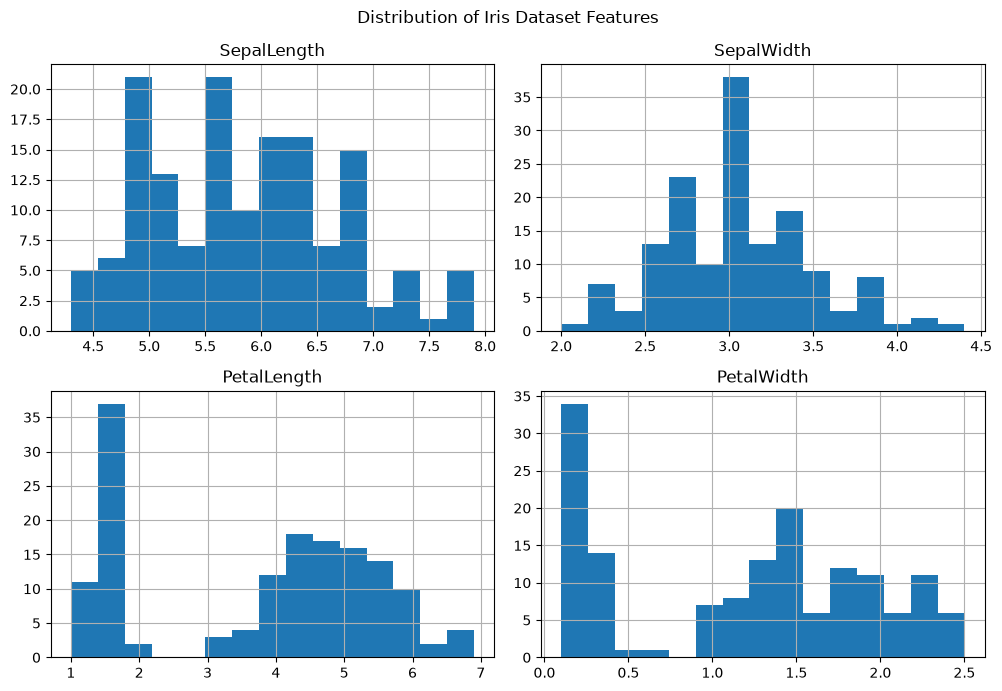

In [14]:
# Visualize the distribution of numerical features

df[
    [
        "SepalLength",
        "SepalWidth",
        "PetalLength",
        "PetalWidth"
    ]
].hist(
    figsize=(10, 7),
    bins=15
)

plt.suptitle("Distribution of Iris Dataset Features")

plt.tight_layout()
plt.show()

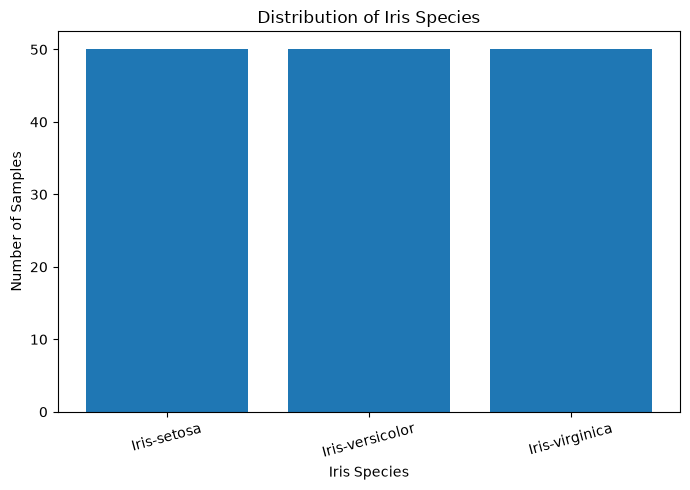

In [15]:
# Visualize the number of samples in each species

plt.figure(figsize=(7, 5))

plt.bar(
    class_counts.index,
    class_counts.values
)

plt.xlabel("Iris Species")
plt.ylabel("Number of Samples")
plt.title("Distribution of Iris Species")

plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [16]:
# Calculate the correlation between numerical features

correlation_matrix = X.corr()

print("Feature Correlation Matrix:")
display(correlation_matrix)

Feature Correlation Matrix:


,SepalLength,SepalWidth,PetalLength,PetalWidth
SepalLength,1.000000,-0.109369,0.871754,0.817954
SepalWidth,-0.109369,1.000000,-0.420516,-0.356544
PetalLength,0.871754,-0.420516,1.000000,0.962757
PetalWidth,0.817954,-0.356544,0.962757,1.000000


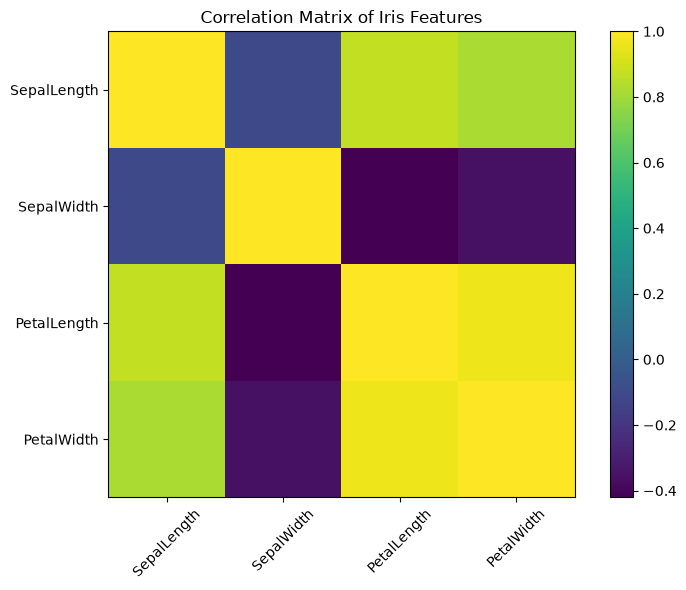

In [17]:
# Visualize the correlation matrix of Iris features

plt.figure(figsize=(8, 6))

plt.imshow(
    correlation_matrix,
    interpolation="nearest"
)

plt.colorbar()

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=45
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

plt.title("Correlation Matrix of Iris Features")

plt.tight_layout()
plt.show()

* TRAIN-TEST SPLIT

In [18]:
# Split the dataset into training and testing subsets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 120
Testing samples: 30


In [19]:
# Standardize feature values for scale-sensitive classification algorithms

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed successfully.")

Feature scaling completed successfully.


* CLASSIFICATION MODELS

In [20]:
# Create the Logistic Regression classifier

logistic_model = LogisticRegression(
    max_iter=200
)

print("Logistic Regression model created.")

Logistic Regression model created.


In [21]:
# Train the Logistic Regression classifier and record training time

start_time = time.time()

logistic_model.fit(
    X_train_scaled,
    y_train
)

logistic_training_time = time.time() - start_time

print("Logistic Regression training completed.")
print("Training time:", round(logistic_training_time, 4), "seconds")

Logistic Regression training completed.
Training time: 0.0915 seconds


In [22]:
# Generate predictions using Logistic Regression

logistic_pred = logistic_model.predict(X_test_scaled)

print("Logistic Regression predictions generated.")
print("First 10 predictions:", logistic_pred[:10])

Logistic Regression predictions generated.
First 10 predictions: [0 2 1 1 0 1 0 0 2 1]


In [23]:
# Create the Decision Tree classifier

decision_tree_model = DecisionTreeClassifier(
    random_state=42
)

print("Decision Tree model created.")

Decision Tree model created.


In [24]:
# Train the Decision Tree classifier

start_time = time.time()

decision_tree_model.fit(
    X_train,
    y_train
)

decision_tree_training_time = time.time() - start_time

print("Decision Tree training completed.")
print("Training time:", round(decision_tree_training_time, 4), "seconds")

Decision Tree training completed.
Training time: 0.0456 seconds


In [25]:
# Generate predictions using Decision Tree

decision_tree_pred = decision_tree_model.predict(X_test)

print("Decision Tree predictions generated.")
print("First 10 predictions:", decision_tree_pred[:10])

Decision Tree predictions generated.
First 10 predictions: [0 2 1 1 0 1 0 0 2 1]


In [26]:
# Create the Random Forest classifier

random_forest_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

print("Random Forest model created.")

Random Forest model created.


In [27]:
# Train the Random Forest classifier

start_time = time.time()

random_forest_model.fit(
    X_train,
    y_train
)

random_forest_training_time = time.time() - start_time

print("Random Forest training completed.")
print("Training time:", round(random_forest_training_time, 4), "seconds")

Random Forest training completed.
Training time: 0.5921 seconds


In [28]:
# Generate predictions using Random Forest

random_forest_pred = random_forest_model.predict(X_test)

print("Random Forest predictions generated.")
print("First 10 predictions:", random_forest_pred[:10])

Random Forest predictions generated.
First 10 predictions: [0 2 1 1 0 1 0 0 2 1]


In [29]:
# Create the Support Vector Machine classifier

svm_model = SVC(
    kernel="rbf"
)

print("SVM model created.")

SVM model created.


In [30]:
# Train the Support Vector Machine classifier

start_time = time.time()

svm_model.fit(
    X_train_scaled,
    y_train
)

svm_training_time = time.time() - start_time

print("SVM training completed.")
print("Training time:", round(svm_training_time, 4), "seconds")

SVM training completed.
Training time: 0.0157 seconds


In [31]:
# Generate predictions using SVM

svm_pred = svm_model.predict(X_test_scaled)

print("SVM predictions generated.")
print("First 10 predictions:", svm_pred[:10])

SVM predictions generated.
First 10 predictions: [0 2 1 1 0 1 0 0 2 1]


In [32]:
# Create the K-Nearest Neighbors classifier

knn_model = KNeighborsClassifier(
    n_neighbors=5
)

print("KNN model created.")

KNN model created.


In [33]:
# Train the K-Nearest Neighbors classifier

start_time = time.time()

knn_model.fit(
    X_train_scaled,
    y_train
)

knn_training_time = time.time() - start_time

print("KNN training completed.")
print("Training time:", round(knn_training_time, 4), "seconds")

KNN training completed.
Training time: 0.0251 seconds


In [35]:
# Generate predictions using KNN

knn_pred = knn_model.predict(X_test_scaled)

print("KNN predictions generated.")
print("First 10 predictions:", knn_pred[:10])

KNN predictions generated.
First 10 predictions: [0 2 1 1 0 1 0 0 2 1]


In [36]:
# Create the Gaussian Naïve Bayes classifier

naive_bayes_model = GaussianNB()

print("Naïve Bayes model created.")

Naïve Bayes model created.


In [37]:
# Train the Naïve Bayes classifier

start_time = time.time()

naive_bayes_model.fit(
    X_train,
    y_train
)

naive_bayes_training_time = time.time() - start_time

print("Naïve Bayes training completed.")
print("Training time:", round(naive_bayes_training_time, 4), "seconds")

Naïve Bayes training completed.
Training time: 0.0097 seconds


In [38]:
# Generate predictions using Naïve Bayes

naive_bayes_pred = naive_bayes_model.predict(X_test)

print("Naïve Bayes predictions generated.")
print("First 10 predictions:", naive_bayes_pred[:10])

Naïve Bayes predictions generated.
First 10 predictions: [0 2 1 1 0 1 0 0 2 1]


* MODEL EVALUATION

In [39]:
# Define a function to calculate classification performance metrics

def evaluate_classifier(y_actual, y_predicted):
    
    accuracy = accuracy_score(y_actual, y_predicted)
    
    precision = precision_score(
        y_actual,
        y_predicted,
        average="weighted"
    )
    
    recall = recall_score(
        y_actual,
        y_predicted,
        average="weighted"
    )
    
    f1 = f1_score(
        y_actual,
        y_predicted,
        average="weighted"
    )
    
    return accuracy, precision, recall, f1

In [40]:
# Calculate performance metrics for all classification algorithms

logistic_accuracy, logistic_precision, logistic_recall, logistic_f1 = evaluate_classifier(
    y_test, logistic_pred
)

decision_tree_accuracy, decision_tree_precision, decision_tree_recall, decision_tree_f1 = evaluate_classifier(
    y_test, decision_tree_pred
)

random_forest_accuracy, random_forest_precision, random_forest_recall, random_forest_f1 = evaluate_classifier(
    y_test, random_forest_pred
)

svm_accuracy, svm_precision, svm_recall, svm_f1 = evaluate_classifier(
    y_test, svm_pred
)

knn_accuracy, knn_precision, knn_recall, knn_f1 = evaluate_classifier(
    y_test, knn_pred
)

naive_bayes_accuracy, naive_bayes_precision, naive_bayes_recall, naive_bayes_f1 = evaluate_classifier(
    y_test, naive_bayes_pred
)

print("All classification models evaluated successfully.")

All classification models evaluated successfully.


In [41]:
# Create a comparison table for all classification algorithms

results = pd.DataFrame({
    
    "Algorithm": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "SVM",
        "KNN",
        "Naïve Bayes"
    ],
    
    "Accuracy": [
        logistic_accuracy,
        decision_tree_accuracy,
        random_forest_accuracy,
        svm_accuracy,
        knn_accuracy,
        naive_bayes_accuracy
    ],
    
    "Precision": [
        logistic_precision,
        decision_tree_precision,
        random_forest_precision,
        svm_precision,
        knn_precision,
        naive_bayes_precision
    ],
    
    "Recall": [
        logistic_recall,
        decision_tree_recall,
        random_forest_recall,
        svm_recall,
        knn_recall,
        naive_bayes_recall
    ],
    
    "F1 Score": [
        logistic_f1,
        decision_tree_f1,
        random_forest_f1,
        svm_f1,
        knn_f1,
        naive_bayes_f1
    ],
    
    "Training Time (sec)": [
        logistic_training_time,
        decision_tree_training_time,
        random_forest_training_time,
        svm_training_time,
        knn_training_time,
        naive_bayes_training_time
    ]
})

results

,Algorithm,Accuracy,Precision,Recall,F1 Score,Training Time (sec)
0,Logistic Regression,0.933333,0.933333,0.933333,0.933333,0.091465
1,Decision Tree,0.933333,0.933333,0.933333,0.933333,0.045629
2,Random Forest,0.900000,0.902357,0.900000,0.899749,0.592142
3,SVM,0.966667,0.969697,0.966667,0.966583,0.015723
4,KNN,0.933333,0.944444,0.933333,0.932660,0.005066
5,Naïve Bayes,0.966667,0.969697,0.966667,0.966583,0.009728


In [42]:
# Round numerical values to make the comparison table easier to read

results_display = results.copy()

metric_columns = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score",
    "Training Time (sec)"
]

results_display[metric_columns] = results_display[metric_columns].round(4)

results_display

,Algorithm,Accuracy,Precision,Recall,F1 Score,Training Time (sec)
0,Logistic Regression,0.9333,0.9333,0.9333,0.9333,0.0915
1,Decision Tree,0.9333,0.9333,0.9333,0.9333,0.0456
2,Random Forest,0.9000,0.9024,0.9000,0.8997,0.5921
3,SVM,0.9667,0.9697,0.9667,0.9666,0.0157
4,KNN,0.9333,0.9444,0.9333,0.9327,0.0051
5,Naïve Bayes,0.9667,0.9697,0.9667,0.9666,0.0097


In [43]:
# Rank classifiers according to their Accuracy

ranking = results.sort_values(
    by="Accuracy",
    ascending=False
).reset_index(drop=True)

ranking["Rank"] = range(1, len(ranking) + 1)

ranking

,Algorithm,Accuracy,Precision,Recall,F1 Score,Training Time (sec),Rank
0,Naïve Bayes,0.966667,0.969697,0.966667,0.966583,0.009728,1
1,SVM,0.966667,0.969697,0.966667,0.966583,0.015723,2
2,Decision Tree,0.933333,0.933333,0.933333,0.933333,0.045629,3
3,Logistic Regression,0.933333,0.933333,0.933333,0.933333,0.091465,4
4,KNN,0.933333,0.944444,0.933333,0.932660,0.005066,5
5,Random Forest,0.900000,0.902357,0.900000,0.899749,0.592142,6


In [44]:
# Automatically identify the best classifier based on Accuracy

best_classifier = results.loc[
    results["Accuracy"].idxmax()
]

print("=" * 55)
print("BEST CLASSIFICATION ALGORITHM")
print("=" * 55)

print("Algorithm :", best_classifier["Algorithm"])
print("Accuracy  :", round(best_classifier["Accuracy"], 4))
print("Precision :", round(best_classifier["Precision"], 4))
print("Recall    :", round(best_classifier["Recall"], 4))
print("F1 Score  :", round(best_classifier["F1 Score"], 4))

BEST CLASSIFICATION ALGORITHM
Algorithm : SVM
Accuracy  : 0.9667
Precision : 0.9697
Recall    : 0.9667
F1 Score  : 0.9666


* VISUAL COMPARISON

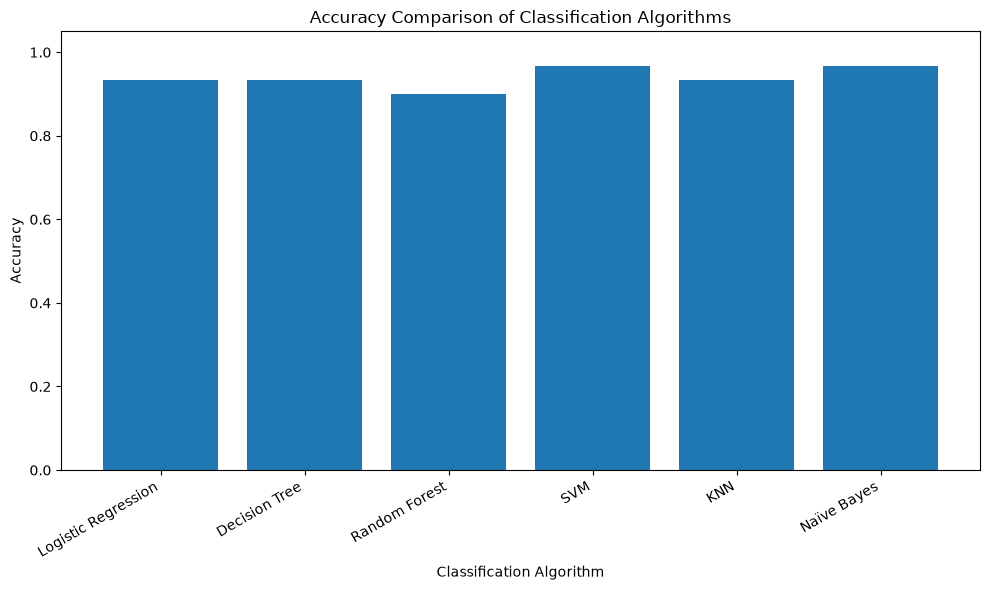

In [45]:
# Compare the accuracy of all classification algorithms

plt.figure(figsize=(10, 6))

plt.bar(
    results["Algorithm"],
    results["Accuracy"]
)

plt.xlabel("Classification Algorithm")
plt.ylabel("Accuracy")
plt.title("Accuracy Comparison of Classification Algorithms")

plt.xticks(rotation=30, ha="right")
plt.ylim(0, 1.05)

plt.tight_layout()
plt.show()

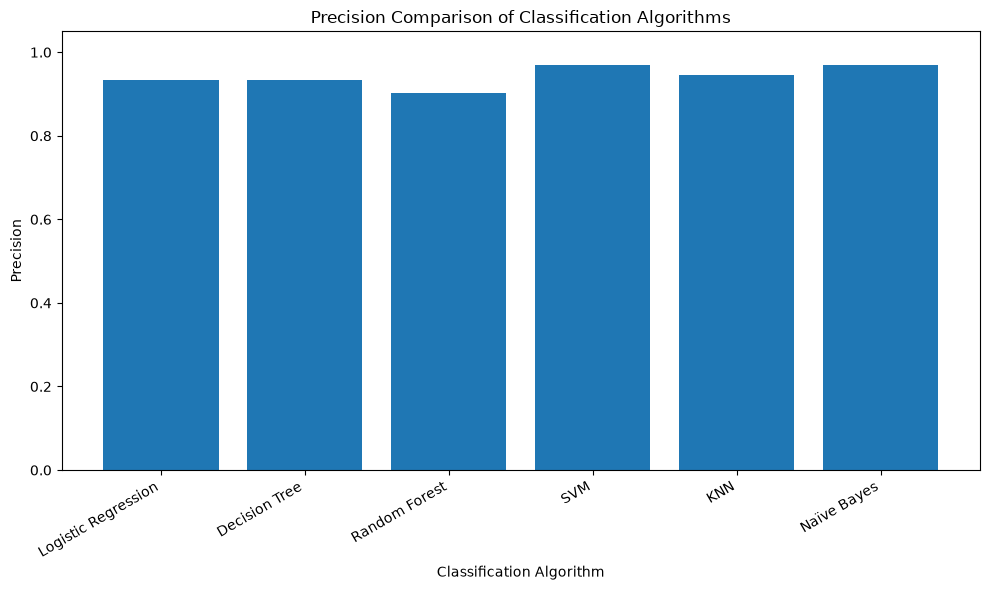

In [46]:
# Compare the precision of all classification algorithms

plt.figure(figsize=(10, 6))

plt.bar(
    results["Algorithm"],
    results["Precision"]
)

plt.xlabel("Classification Algorithm")
plt.ylabel("Precision")
plt.title("Precision Comparison of Classification Algorithms")

plt.xticks(rotation=30, ha="right")
plt.ylim(0, 1.05)

plt.tight_layout()
plt.show()

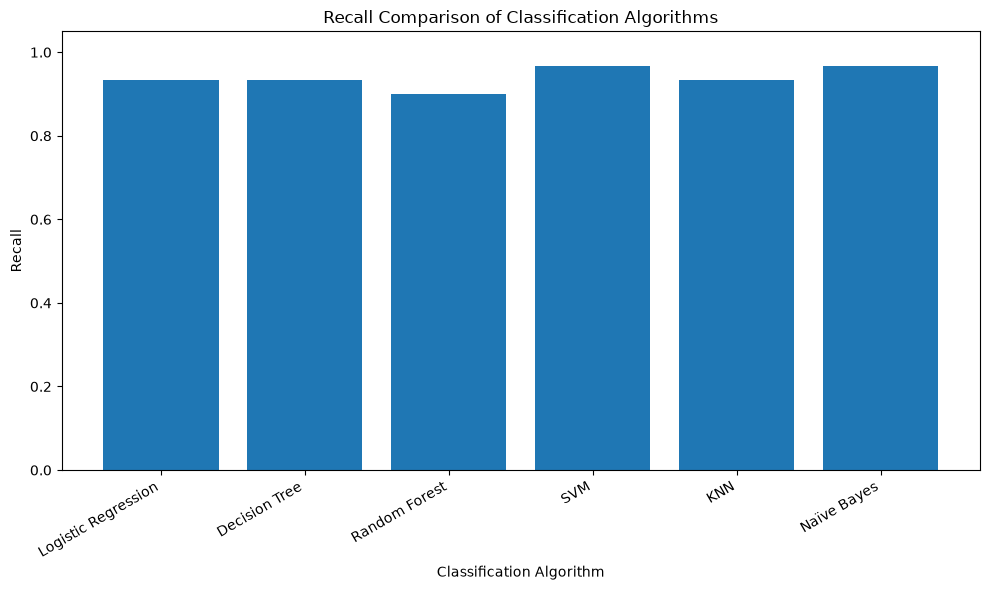

In [47]:
# Compare the recall of all classification algorithms

plt.figure(figsize=(10, 6))

plt.bar(
    results["Algorithm"],
    results["Recall"]
)

plt.xlabel("Classification Algorithm")
plt.ylabel("Recall")
plt.title("Recall Comparison of Classification Algorithms")

plt.xticks(rotation=30, ha="right")
plt.ylim(0, 1.05)

plt.tight_layout()
plt.show()

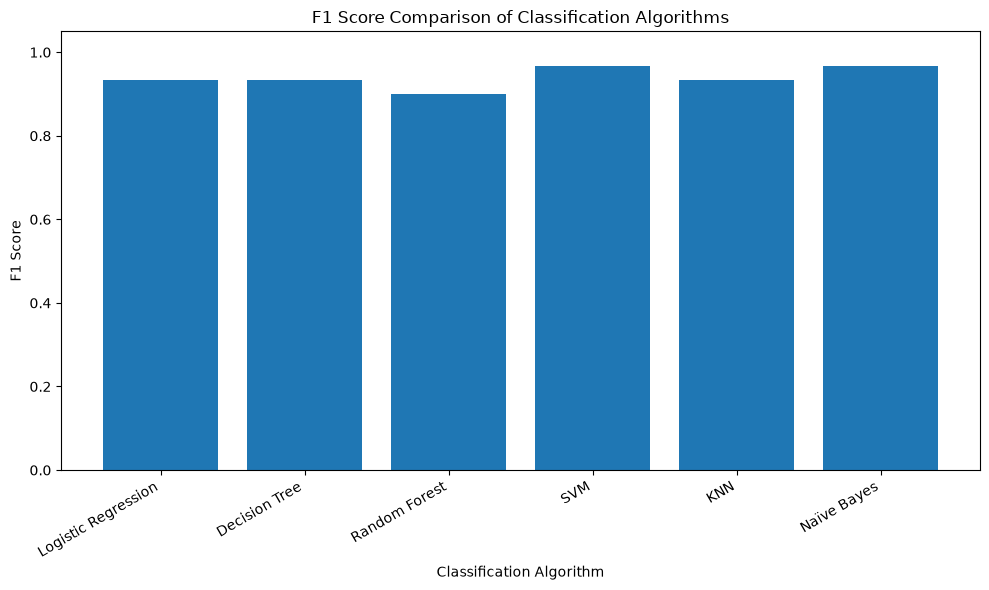

In [48]:
# Compare the F1 scores of all classification algorithms

plt.figure(figsize=(10, 6))

plt.bar(
    results["Algorithm"],
    results["F1 Score"]
)

plt.xlabel("Classification Algorithm")
plt.ylabel("F1 Score")
plt.title("F1 Score Comparison of Classification Algorithms")

plt.xticks(rotation=30, ha="right")
plt.ylim(0, 1.05)

plt.tight_layout()
plt.show()

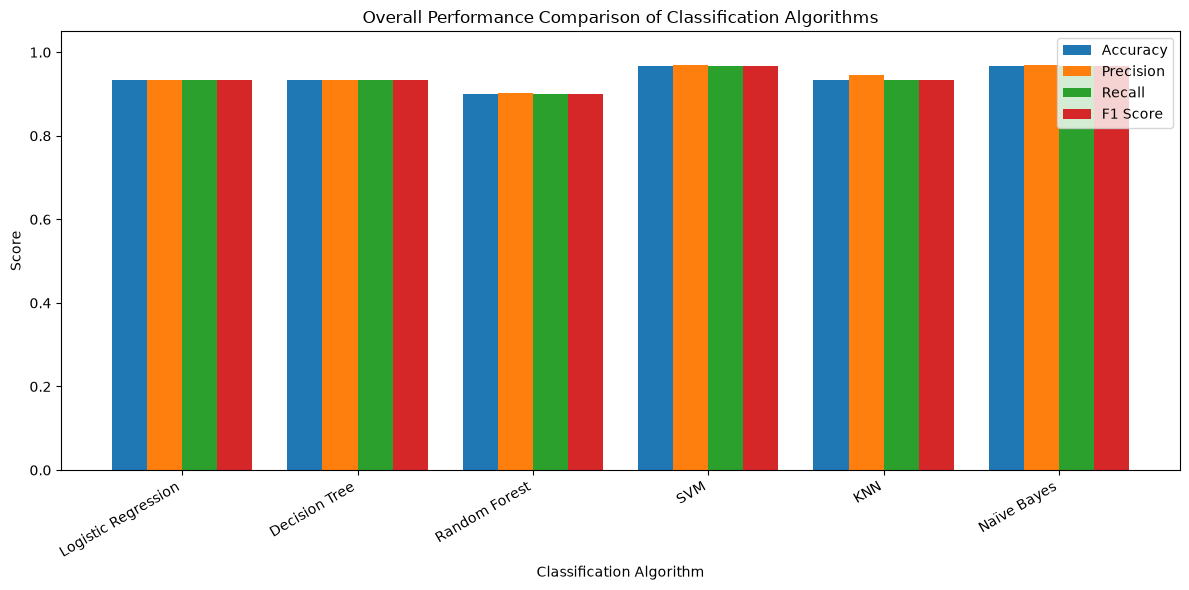

In [49]:
# Compare Accuracy, Precision, Recall and F1 Score together

metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score"
]

x = np.arange(len(results["Algorithm"]))
width = 0.2

plt.figure(figsize=(12, 6))

for i, metric in enumerate(metrics):
    plt.bar(
        x + i * width,
        results[metric],
        width,
        label=metric
    )

plt.xlabel("Classification Algorithm")
plt.ylabel("Score")
plt.title("Overall Performance Comparison of Classification Algorithms")

plt.xticks(
    x + width * 1.5,
    results["Algorithm"],
    rotation=30,
    ha="right"
)

plt.ylim(0, 1.05)
plt.legend()

plt.tight_layout()
plt.show()

In [50]:
# Store predictions of all classifiers for confusion matrix analysis

predictions = {
    "Logistic Regression": logistic_pred,
    "Decision Tree": decision_tree_pred,
    "Random Forest": random_forest_pred,
    "SVM": svm_pred,
    "KNN": knn_pred,
    "Naïve Bayes": naive_bayes_pred
}

print("Predictions stored successfully.")

Predictions stored successfully.


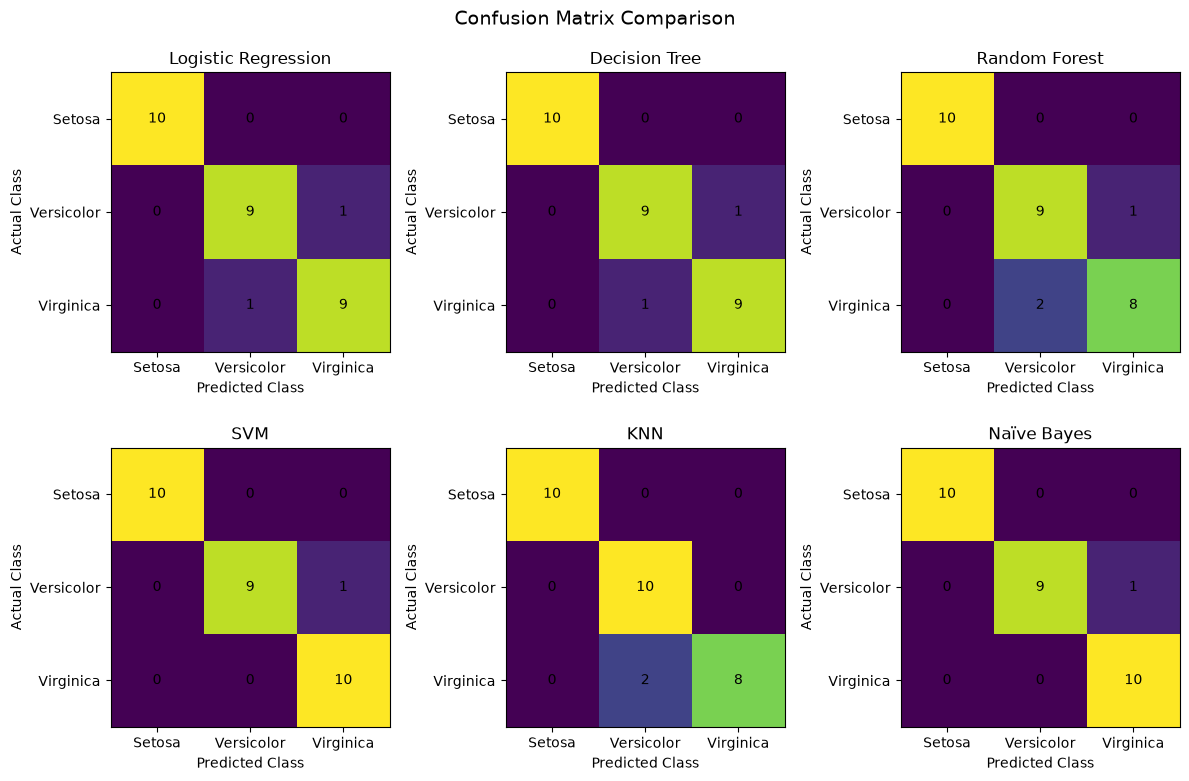

In [51]:
# Display confusion matrices for all classification algorithms

class_names = label_encoder.classes_

fig, axes = plt.subplots(
    2,
    3,
    figsize=(12, 8)
)

for ax, (model_name, prediction) in zip(
    axes.ravel(),
    predictions.items()
):
    
    cm = confusion_matrix(
        y_test,
        prediction
    )
    
    ax.imshow(cm)
    
    ax.set_title(model_name)
    ax.set_xlabel("Predicted Class")
    ax.set_ylabel("Actual Class")
    
    ax.set_xticks(range(3))
    ax.set_yticks(range(3))
    
    ax.set_xticklabels(["Setosa", "Versicolor", "Virginica"])
    ax.set_yticklabels(["Setosa", "Versicolor", "Virginica"])
    
    for i in range(3):
        for j in range(3):
            ax.text(
                j,
                i,
                cm[i, j],
                ha="center",
                va="center"
            )

plt.suptitle("Confusion Matrix Comparison", fontsize=14)

plt.tight_layout()
plt.show()

In [52]:
# Display the detailed classification report for the best classifier

best_model_name = best_classifier["Algorithm"]

best_prediction = predictions[best_model_name]

print("Best Classifier:", best_model_name)
print("\nDetailed Classification Report:\n")

print(
    classification_report(
        y_test,
        best_prediction,
        target_names=[
            "Iris-setosa",
            "Iris-versicolor",
            "Iris-virginica"
        ]
    )
)

Best Classifier: SVM

Detailed Classification Report:

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      0.90      0.95        10
 Iris-virginica       0.91      1.00      0.95        10

       accuracy                           0.97        30
      macro avg       0.97      0.97      0.97        30
   weighted avg       0.97      0.97      0.97        30



In [55]:
# Predict the species of a new flower using the best classifier

new_flower = pd.DataFrame(
    [[5.1, 3.5, 1.4, 0.2]],
    columns=[
        "SepalLength",
        "SepalWidth",
        "PetalLength",
        "PetalWidth"
    ]
)

new_flower_scaled = scaler.transform(new_flower)

if best_model_name == "Logistic Regression":
    prediction = logistic_model.predict(new_flower_scaled)

elif best_model_name == "Decision Tree":
    prediction = decision_tree_model.predict(new_flower)

elif best_model_name == "Random Forest":
    prediction = random_forest_model.predict(new_flower)

elif best_model_name == "SVM":
    prediction = svm_model.predict(new_flower_scaled)

elif best_model_name == "KNN":
    prediction = knn_model.predict(new_flower_scaled)

else:
    prediction = naive_bayes_model.predict(new_flower)

predicted_species = label_encoder.inverse_transform(prediction)

print("New Flower Measurements:")
print("Sepal Length : 5.1 cm")
print("Sepal Width  : 3.5 cm")
print("Petal Length : 1.4 cm")
print("Petal Width  : 0.2 cm")

print("\nPredicted Species:", predicted_species[0])

New Flower Measurements:
Sepal Length : 5.1 cm
Sepal Width  : 3.5 cm
Petal Length : 1.4 cm
Petal Width  : 0.2 cm

Predicted Species: Iris-setosa


In [56]:
# Display the final result of the classification experiment

print("=" * 65)
print("FINAL CLASSIFICATION EXPERIMENT RESULT")
print("=" * 65)

print("\nBest Algorithm :", best_classifier["Algorithm"])
print("Accuracy       :", round(best_classifier["Accuracy"], 4))
print("Precision      :", round(best_classifier["Precision"], 4))
print("Recall         :", round(best_classifier["Recall"], 4))
print("F1 Score       :", round(best_classifier["F1 Score"], 4))

FINAL CLASSIFICATION EXPERIMENT RESULT

Best Algorithm : SVM
Accuracy       : 0.9667
Precision      : 0.9697
Recall         : 0.9667
F1 Score       : 0.9666


### Conclusion

In this experiment, six different classification algorithms, namely Logistic
Regression, Decision Tree, Random Forest, Support Vector Machine (SVM),
K-Nearest Neighbors (KNN) and Naïve Bayes, were implemented on the Iris dataset.

The classifiers were evaluated using Accuracy, Precision, Recall and F1-Score.
Their performance was compared using numerical results, graphical
visualizations and confusion matrices.

The best-performing algorithm was identified based on its classification
performance. The experiment demonstrates that different classification
algorithms can produce different results depending on the characteristics
of the dataset.

Therefore, comparing multiple classifiers provides a systematic approach
for selecting a suitable machine learning model for a given classification
problem.